In [ ]:
import pandas as pd
import numpy as np
from pyfaidx import Fasta
from scipy.stats import mode

import seaborn as sns
# plotting modules
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as colors
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.sans-serif'] = "Arial" # missing fonts:: https://alexanderlabwhoi.github.io/post/2021-03-missingfont/
# Then, "ALWAYS use sans-serif fonts"
matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams.update({'font.size': 7, 'axes.linewidth': 1, 'xtick.major.width': 1, 'xtick.major.size': 1.5, 'ytick.major.width': 1, 'ytick.major.size': 1.5})
from matplotlib.backends.backend_pdf import PdfPages

genome_fasta = "/data5/deepro/genomes/hg38/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta"
genome = Fasta(genome_fasta, as_raw=True)

In [45]:
def save_pdf(save_file, fig):
    pdf = PdfPages(save_file)
    pdf.savefig(fig, bbox_inches='tight', dpi=300)
    pdf.close()
    return


In [2]:
df = pd.read_csv("/data7/deepro/starrseq/4_ml_classification_fragment_category/data/CC/linear/homer/motif_odds.tsv", sep="\t")

In [30]:
p53_motifs = ["P53_HUMAN.H11MO.0.A", "P63_HUMAN.H11MO.0.A", "P73_HUMAN.H11MO.0.A"]
atf2_motifs = ['ATF2_HUMAN.H11MO.0.B', ] # 'ATF1_HUMAN.H11MO.0.B', 'ATF3_HUMAN.H11MO.0.A', 
atf4_motifs = ['ATF4_HUMAN.H11MO.0.A']
lib = "CC"


In [42]:
def create_seq_attr_df(seq, seq_attr):
    data_arr = np.zeros((len(seq), 4))
    nts = ["A", "T", "G", "C"]
    seq_idx = dict(zip(nts, range(len(nts))))
    for i, (s, sq) in enumerate(zip(seq, seq_attr)):
        data_arr[i, seq_idx[s]] = sq
    data_df = pd.DataFrame(data_arr, columns=nts)
    return data_df

def get_complement(seq):
    complement_dict = {
        "A": "T",
        "G": "C",
        "T": "A",
        "C": "G"
        }    
    rev_comp_seq = "".join([complement_dict[s] for s in seq])
    return rev_comp_seq

def get_seq_info(df, idx, genome, seq_attr_arr, reverse=False):
    chrm, start, end = df.iloc[idx].loc[[2, 3, 4]].values
    seq = list(genome.get_seq(chrm, start, end))
    if reverse:
        seq = get_complement(seq)
    seq_attr = np.sum(seq_attr_arr[idx], axis=0)
    return seq, seq_attr, (chrm, start, end)

def col_mode(arr):
    modes, freqs = [], []
    for col in arr.T:  # iterate columns
        vals, counts = np.unique(col, return_counts=True)
        idx = np.argmax(counts)
        modes.append(vals[idx])   # most frequent base
        freqs.append(counts[idx]) # its count
    return np.array(modes), np.array(freqs)

def create_flanking_sequence_plot(motifs, lib, flanks=50, slide=5, ytop=0.06):
    tf_family_regs_df = df.loc[
        (df["Motif Name"].isin(motifs))&
        (df["Strand"] == "+")
    ]
    nlinear_pred_file = f"/data7/deepro/starrseq/4_ml_classification_fragment_category/data/{lib}/resnet_mlp.csv.gz"
    pred_df = pd.read_csv(nlinear_pred_file, header=None, names=["ypred", "y", "chrm", "start", "end"])
    pred_df["start"] = pred_df["start"].astype(str)
    pred_df["end"] = pred_df["end"].astype(str)

    tf_family_regs_df[["chrm", "start", "end"]] = tf_family_regs_df["PositionID"].str.split("_", expand=True)
    tf_lib_pred_df = tf_family_regs_df.merge(pred_df.reset_index().rename(columns={"index": "pred_index"}), on=["chrm", "start", "end"]).sort_values("ypred")
    tf_lib_pred_df = tf_lib_pred_df.loc[tf_lib_pred_df.groupby(["PositionID", "pred_index"])["MotifScore"].apply(lambda ser: ser.idxmax())].sort_values("ypred")

    hc_peaks_df = tf_lib_pred_df.loc[
        (tf_lib_pred_df["ypred"]>0.9)&
        (tf_lib_pred_df["y"]==1)
    ]

    seq_arr_file = f"/data7/deepro/starrseq/4_ml_classification_fragment_category/data/{lib}/seq_attr.npy"
    seq_attr_arr = np.load(seq_arr_file)

    attr_array_peaks = []
    attr_array_peak_seq = []
    attr_array_nonpeaks = []

    for idx, row in hc_peaks_df.iterrows():
        chrm, start, end = row.chrm, row.start, row.end
        start = int(start)
        end = int(end)
        seq = genome.get_seq(chrm, int(start), int(end))
        seq_attr = np.sum(seq_attr_arr[row.pred_index], axis=0)
        start, end = row.Offset-flanks+slide, row.Offset+flanks+slide
        subseq = seq[start:end]
        if start<0 or end>len(seq_attr):
            continue
        attr = seq_attr[start:end]
        attr_array_peaks.append(attr)
        attr_array_peak_seq.append(list(subseq))

        select_random_regions = np.random.randint(0, 1000, 2*flanks)
        attr = seq_attr[select_random_regions]
        attr_array_nonpeaks.append(attr)

    attr_array_peaks = np.array(attr_array_peaks)
    attr_array_nonpeaks = np.array(attr_array_nonpeaks)

    df_attr_array_peaks = pd.DataFrame(attr_array_peaks).melt()
    df_attr_array_peaks["type"] = "peak"

    df_attr_array_nonpeaks = pd.DataFrame(attr_array_nonpeaks).melt()
    df_attr_array_nonpeaks["type"] = "non-peak"

    df_plot = pd.concat([df_attr_array_peaks, df_attr_array_nonpeaks])
    df_plot["value"] = df_plot["value"].abs()

    fig, ax = plt.subplots(figsize=(7.5,2))
    sns.pointplot(
        data=df_plot, x="variable", y="value", hue="type", palette=["dodgerblue", "lightgrey"], order=list(range(2*flanks)), ax=ax, 
        markersize=5, linewidth=1,
        ) # fliersize=0
    ax.set_ylim(-0.01, ytop)

    seq_arr = np.array(attr_array_peak_seq)
    most_freq, counts = col_mode(seq_arr)

    color_dict = {
        "A": "green",
        "T": "red",
        "G": "orange",
        "C": "blue"
    }
    sizes = df_attr_array_peaks.groupby("variable").agg({"value": lambda x: np.mean(np.abs(x))}).values.flatten()
    sizes = 4 + (sizes - sizes.min()) * (10 - 4) / (sizes.max() - sizes.min())
    for i in range(len(most_freq)):
        ax.text(i, -0.001, most_freq[i], ha='center', va='bottom', fontsize=sizes[i], color=color_dict[most_freq[i]])
    ax.xaxis.set_visible(False) 
    ax.spines[["top", "bottom", "right"]].set_visible(False)
    return fig

/data5/deepro/miniconda3/envs/starrseq/lib/python3.9/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


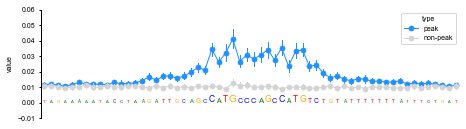

In [43]:
fig = create_flanking_sequence_plot(p53_motifs, lib, flanks=30, slide=10)

In [46]:
save_pdf("/data7/deepro/starrseq/papers/results/4_ml_classification_fragment_category/data/figures/p53_flanking_seq.pdf", fig)

/data5/deepro/miniconda3/envs/starrseq/lib/python3.9/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


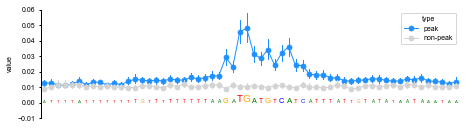

In [47]:
fig = create_flanking_sequence_plot(atf2_motifs, lib, flanks=30, slide=5)

In [48]:
save_pdf("/data7/deepro/starrseq/papers/results/4_ml_classification_fragment_category/data/figures/atf2_flanking_seq.pdf", fig)

/data5/deepro/miniconda3/envs/starrseq/lib/python3.9/site-packages/pandas/core/frame.py:3641: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]


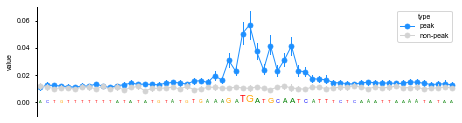

In [49]:
fig = create_flanking_sequence_plot(atf4_motifs, lib, flanks=30, slide=5,ytop=0.07)

In [50]:
save_pdf("/data7/deepro/starrseq/papers/results/4_ml_classification_fragment_category/data/figures/atf4_flanking_seq.pdf", fig)

In [25]:
most_freq

array(['T', 'T', 'T', 'A', 'A', 'A', 'A', 'T', 'G', 'A', 'T', 'T', 'G',
       'T', 'A', 'G', 'A', 'T', 'T', 'T', 'T', 'G', 'A', 'G', 'T', 'T',
       'A', 'G', 'A', 'A', 'A', 'A', 'A', 'T', 'A', 'C', 'C', 'T', 'G',
       'A', 'G', 'A', 'T', 'T', 'G', 'C', 'A', 'G', 'C', 'C', 'A', 'T',
       'G', 'C', 'C', 'C', 'A', 'G', 'C', 'C', 'A', 'T', 'G', 'T', 'C',
       'T', 'G', 'T', 'A', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'A', 'T',
       'T', 'T', 'C', 'T', 'G', 'A', 'T', 'G', 'A', 'T', 'C', 'T', 'A',
       'G', 'T', 'G', 'A', 'A', 'T', 'T', 'G', 'A'], dtype='<U1')

In [4]:
likely_p53_regions = [
    "chr9_115944060_115945060",
    "chr16_8958056_89455906",
    "chr1_202056120_202057120",
    "chr19_461133345_461134345",
    "chr18_57980550_57981550",
    "chr6_112330750_112331750",
    "chr17_69607095_69608095",
    "chr11_3615449_3616449",
    "chr14_103244090_103245090",
    "chr4_41144486_41145486",
    "chr5_174328148_174329148",
    "chr5_10528157_10529157",
    "chr16_86501756_86502756",
    "chr19_49272074_49273074",
    "chr8_37535084_37536084",
    "chr8_142815151_142816151",
    "chr22_38716150_38717150",
    "chr17_42671901_42672901",
    "chr1_233179676_233180676",
    "chr7_30551055_30552055",
    "chr9_107737870_107738870",
    "chr17_34400875_34401875",
    "chr14_70011049_70012049",
    "chr5_174328398_174329398",
    "chr3_195187300_195188300",
    "chr9_92146950_92147950",
    "chr7_117273935_117274935",
    "chr1_202056370_202057370",
    "chr5_133040892_133041892",
    "chr7_42494331_42495331",
    "chr13_41402102_41403102",
    "chr3_42823121_42824121",
    "chr1_9890532_9891532",
    "chr18_26746570_26747570",
    "chr22_25061458_25062458",
    "chr14_51123544_51124544",
    ""

]

likely_ap1_regions = [
    "chr22_39773573_39774573",
    "chr7_141460464_141461464",
    "chr5_53031123_53032123",
    "chr7_106568741_106569741",
    "chr15_36333959_36334959",
    "chr15_29550677_29551677",
    "chr14_36768897_36769897",
    "chr6_136325795_136326795",
    "chr18_48934123_48935123",
    "chr6_3338604_3339604",
    "chr1_46285444_46286444",
    "chr17_20943749_20944749",
    "chr5_34625827_34626827",
    "chr15_56040196_56041196",
    "chr5_174624534_174625534",
    "chr2_85445505_85446505",
    "chr10_16950866_16951866",
    "chr6_42224605_42225605",
    "chr12_45259544_45260544",
    "chr15_36333709_36334709",
    "chr7_2158121_2159121",
    "chr17_20943249_20944249",
    "chr22_17943056_17944056",
    "chr2_235050615_235051615",
    "chr1_31954289_31955289",
    "chr18_49744383_49745383",
    "chr2_56448262_56449262",
    "chr10_33484450_33485450",
    "chr20_10659700_10660700",
    "chr6_42224355_42225355",
    "chr18_49744133_49745133",
    "chr2_25821800_25822800",
    ""
]